# Análise das Unidades Básicas de Saúde (UBS) no Brasil

In [1]:
# Bibliotecas essenciais para ciência de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual dos gráficos
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [2]:
# Liberar leitura do Drive
from google.colab import drive
drive.mount('/content/drive')

# Leitura do arquivo
df = pd.read_csv(
    '/content/drive/MyDrive/FDIA/atividade_sus/Unidades_Basicas_Saude-UBS.csv',
    sep=';',
    encoding='utf-8',
    low_memory=False
)

df.head(3)

Mounted at /content/drive


,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"


In [4]:
# Mapeamento de códigos UF → sigla
uf_map = {
    11:'RO', 12:'AC', 13:'AM', 14:'RR', 15:'PA', 16:'AP', 17:'TO',
    21:'MA', 22:'PI', 23:'CE', 24:'RN', 25:'PB', 26:'PE', 27:'AL',
    28:'SE', 29:'BA', 31:'MG', 32:'ES', 33:'RJ', 35:'SP',
    41:'PR', 42:'SC', 43:'RS', 50:'MS', 51:'MT', 52:'GO', 53:'DF'
}
df['UF_SIGLA'] = df['UF'].map(uf_map)

# Corrigir LONGITUDE (vírgula → ponto decimal) e converter para float
df['LONGITUDE'] = df['LONGITUDE'].astype(str).str.replace(',', '.', regex=False)
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'], errors='coerce')

print(f"Total de UBS no dataset: {len(df):,}")
print(f"Estados cobertos       : {df['UF_SIGLA'].nunique()}")
print(f"Municípios cobertos    : {df['IBGE'].nunique():,}")
print(f"UBS sem coordenadas    : {df['LATITUDE'].isnull().sum():,} ({df['LATITUDE'].isnull().mean()*100:.1f}%)")

Total de UBS no dataset: 47,673
Estados cobertos       : 27
Municípios cobertos    : 5,483
UBS sem coordenadas    : 1,929 (4.0%)


## Análise 1 — Dados Faltantes

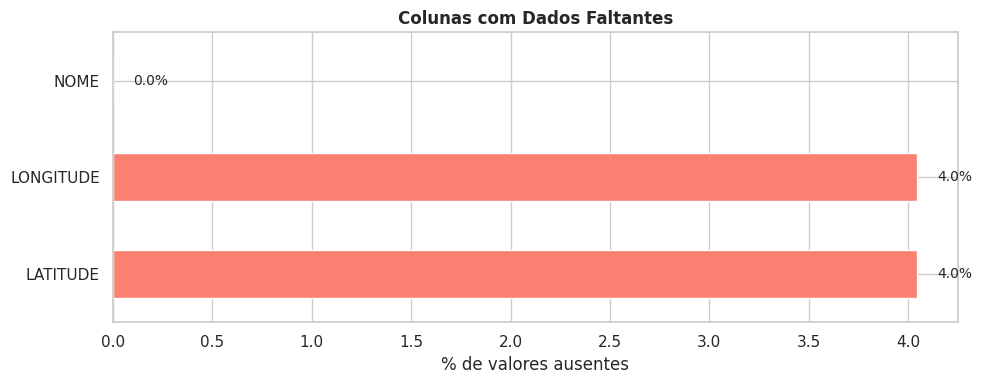

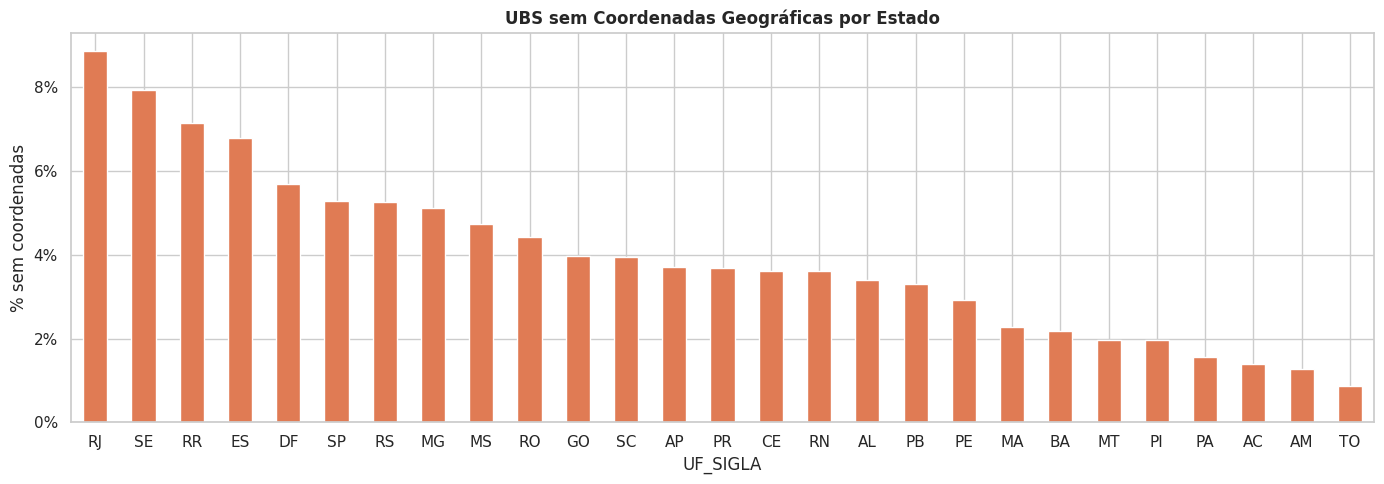


Estado com mais UBS sem coordenadas: RJ (8.9%)


In [5]:
# Percentual de valores ausentes por coluna
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_top = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 4))
missing_top.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Colunas com Dados Faltantes', fontweight='bold')
for i, v in enumerate(missing_top.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# UBS sem coordenadas por estado
sem_coord = df[df['LATITUDE'].isnull()].groupby('UF_SIGLA').size()
total_uf   = df.groupby('UF_SIGLA').size()
pct_sem    = (sem_coord / total_uf * 100).sort_values(ascending=False).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
pct_sem.plot(kind='bar', color='#E07B54', ax=ax, rot=0)
ax.set_ylabel('% sem coordenadas')
ax.set_title('UBS sem Coordenadas Geográficas por Estado', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(f"\nEstado com mais UBS sem coordenadas: {pct_sem.idxmax()} ({pct_sem.max():.1f}%)")

## Análise 2 — Distribuição por Estado (UF)

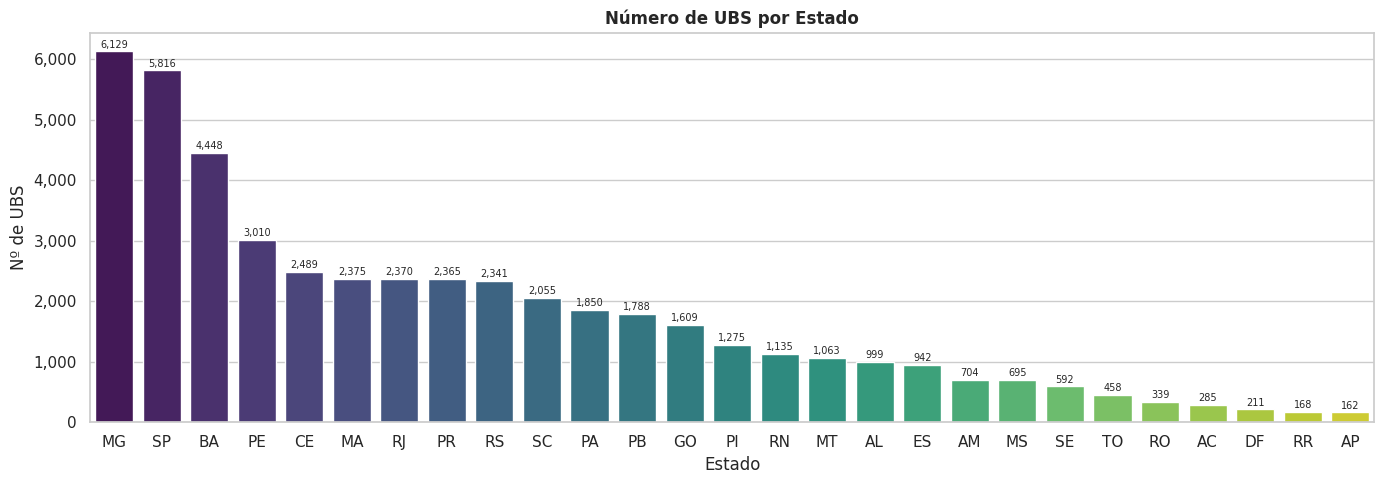


🔺 Estado com mais UBS : MG (6,129)
🔻 Estado com menos UBS: AP (162)

Média de UBS por estado: 1766


In [6]:
por_uf = df['UF_SIGLA'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=por_uf.index, y=por_uf.values, palette='viridis', ax=ax)
ax.set_xlabel('Estado')
ax.set_ylabel('Nº de UBS')
ax.set_title('Número de UBS por Estado', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

print(f"\n🔺 Estado com mais UBS : {por_uf.idxmax()} ({por_uf.max():,})")
print(f"🔻 Estado com menos UBS: {por_uf.idxmin()} ({por_uf.min():,})")
print(f"\nMédia de UBS por estado: {por_uf.mean():.0f}")

## Análise 3 — Cobertura por Município

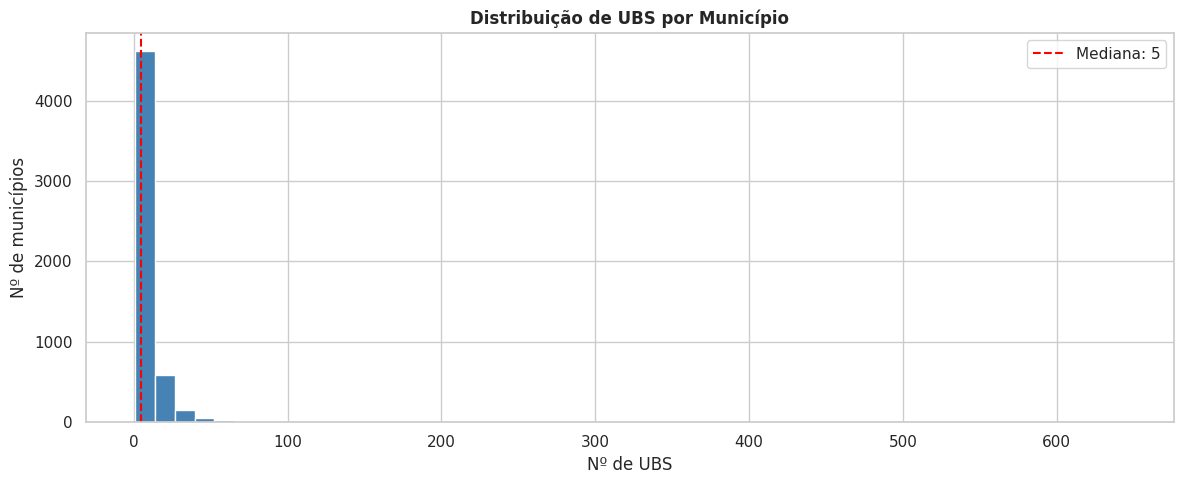

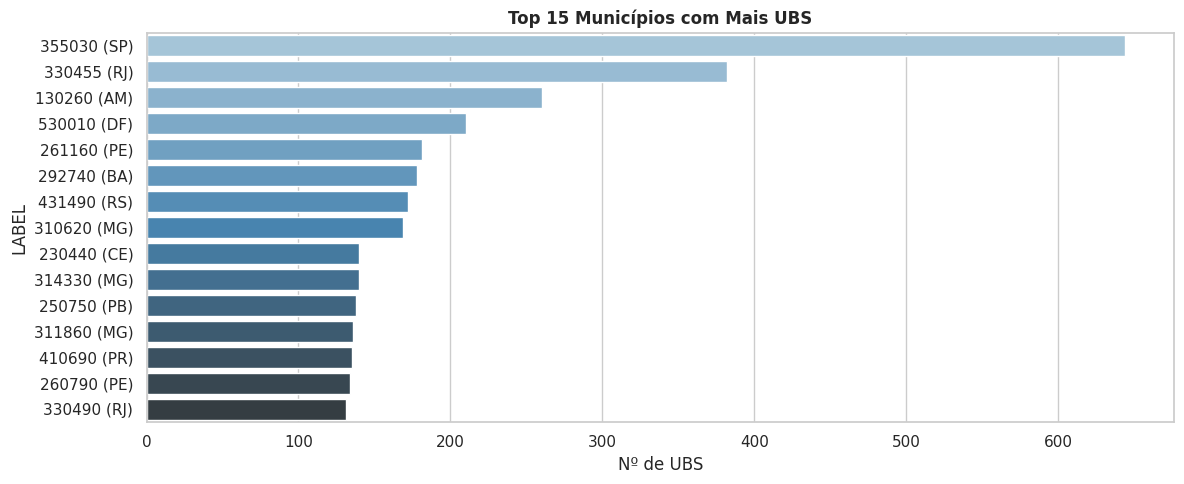

Municípios com apenas 1 UBS: 722 (13.2%)
Média de UBS por município  : 8.7
Mediana de UBS por município: 5


In [7]:
ubs_por_mun = df.groupby(['IBGE', 'UF_SIGLA']).size().reset_index(name='QTD_UBS')

# Histograma da distribuição
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(ubs_por_mun['QTD_UBS'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Nº de UBS')
ax.set_ylabel('Nº de municípios')
ax.set_title('Distribuição de UBS por Município', fontweight='bold')
mediana = ubs_por_mun['QTD_UBS'].median()
ax.axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.0f}')
ax.legend()
plt.tight_layout()
plt.show()

# Top 15 municípios
top_mun = ubs_por_mun.sort_values('QTD_UBS', ascending=False).head(15).copy()
top_mun['LABEL'] = top_mun['IBGE'].astype(str) + ' (' + top_mun['UF_SIGLA'] + ')'

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x='QTD_UBS', y='LABEL', data=top_mun, palette='Blues_d', ax=ax)
ax.set_xlabel('Nº de UBS')
ax.set_title('Top 15 Municípios com Mais UBS', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Municípios com apenas 1 UBS: {(ubs_por_mun['QTD_UBS']==1).sum():,} ({(ubs_por_mun['QTD_UBS']==1).mean()*100:.1f}%)")
print(f"Média de UBS por município  : {ubs_por_mun['QTD_UBS'].mean():.1f}")
print(f"Mediana de UBS por município: {ubs_por_mun['QTD_UBS'].median():.0f}")

## Análise 4 — Tipos de Unidade pelo Nome

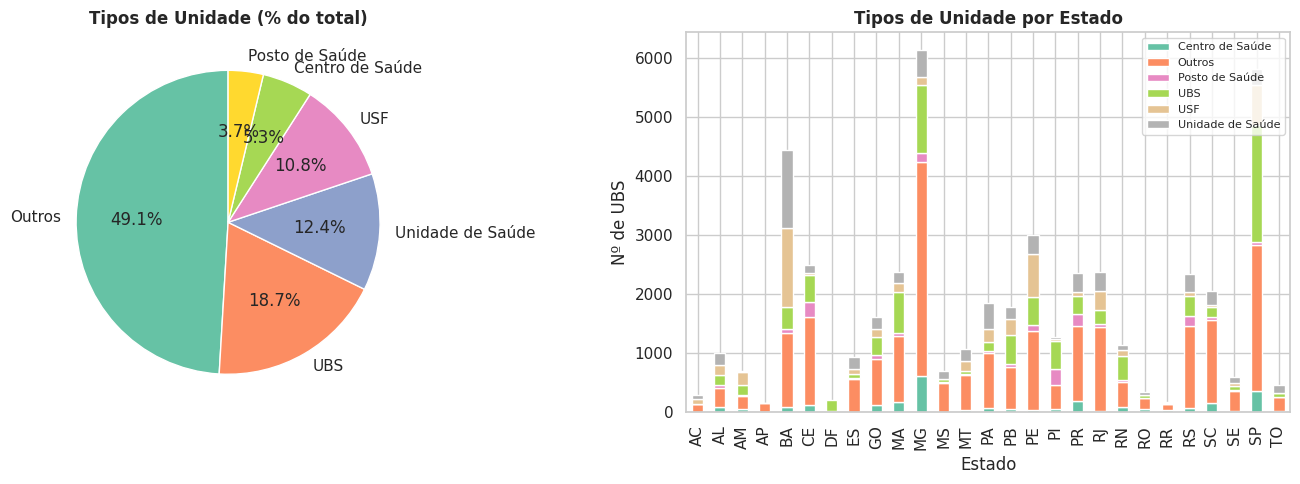


Contagem por tipo de unidade:
  Outros                    23,391 (49.1%)
  UBS                        8,900 (18.7%)
  Unidade de Saúde           5,927 (12.4%)
  USF                        5,128 (10.8%)
  Centro de Saúde            2,545 (5.3%)
  Posto de Saúde             1,782 (3.7%)


In [8]:
# Classificar pelo prefixo/conteúdo do nome
def classificar_tipo(nome):
    nome = str(nome).upper()
    if nome.startswith('UBS'):             return 'UBS'
    elif nome.startswith('USF'):           return 'USF'
    elif 'CENTRO DE SAUDE' in nome or nome.startswith('CS '): return 'Centro de Saúde'
    elif 'UNIDADE DE SAUDE' in nome:       return 'Unidade de Saúde'
    elif 'POSTO DE SAUDE' in nome or nome.startswith('PS '): return 'Posto de Saúde'
    else:                                  return 'Outros'

df['TIPO_UNIDADE'] = df['NOME'].apply(classificar_tipo)
tipo_count = df['TIPO_UNIDADE'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pizza
axes[0].pie(tipo_count.values, labels=tipo_count.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(tipo_count)), startangle=90)
axes[0].set_title('Tipos de Unidade (% do total)', fontweight='bold')

# Stacked bar por estado
tipo_uf = df.groupby(['UF_SIGLA', 'TIPO_UNIDADE']).size().unstack(fill_value=0)
tipo_uf.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Nº de UBS')
axes[1].set_title('Tipos de Unidade por Estado', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print("\nContagem por tipo de unidade:")
for tipo, qtd in tipo_count.items():
    print(f"  {tipo:<25} {qtd:>6,} ({qtd/len(df)*100:.1f}%)")

## Análise 5 — Bairros com Maior Concentração de UBS

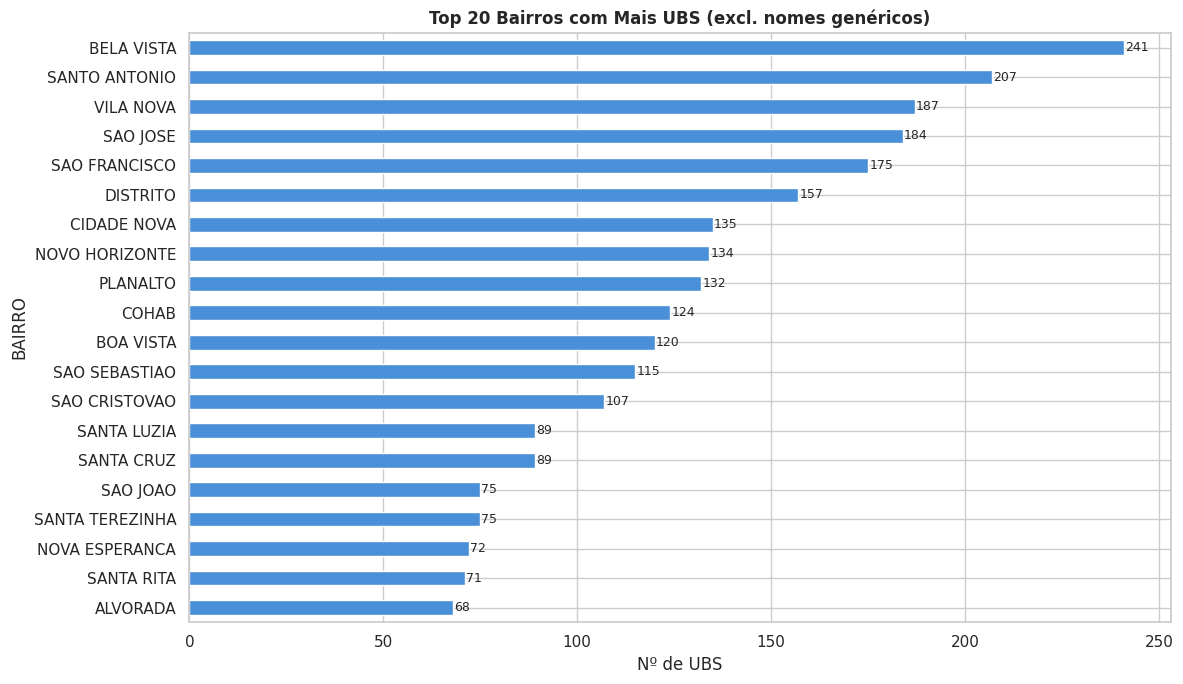


Bairro com mais UBS: BELA VISTA (241 unidades)


In [9]:
# Excluir categorias genéricas que não representam bairros reais
excluir = ['CENTRO', 'ZONA RURAL', 'RURAL', 'INTERIOR', 'POVOADO', '']
top_bairros = (
    df[~df['BAIRRO'].str.upper().isin(excluir)]
    .groupby('BAIRRO').size()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
top_bairros.sort_values().plot(kind='barh', color='#4A90D9', ax=ax)
ax.set_xlabel('Nº de UBS')
ax.set_title('Top 20 Bairros com Mais UBS (excl. nomes genéricos)', fontweight='bold')
for i, v in enumerate(top_bairros.sort_values().values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nBairro com mais UBS: {top_bairros.idxmax()} ({top_bairros.max()} unidades)")

## Análise 6 — Dispersão Geográfica das UBS no Brasil

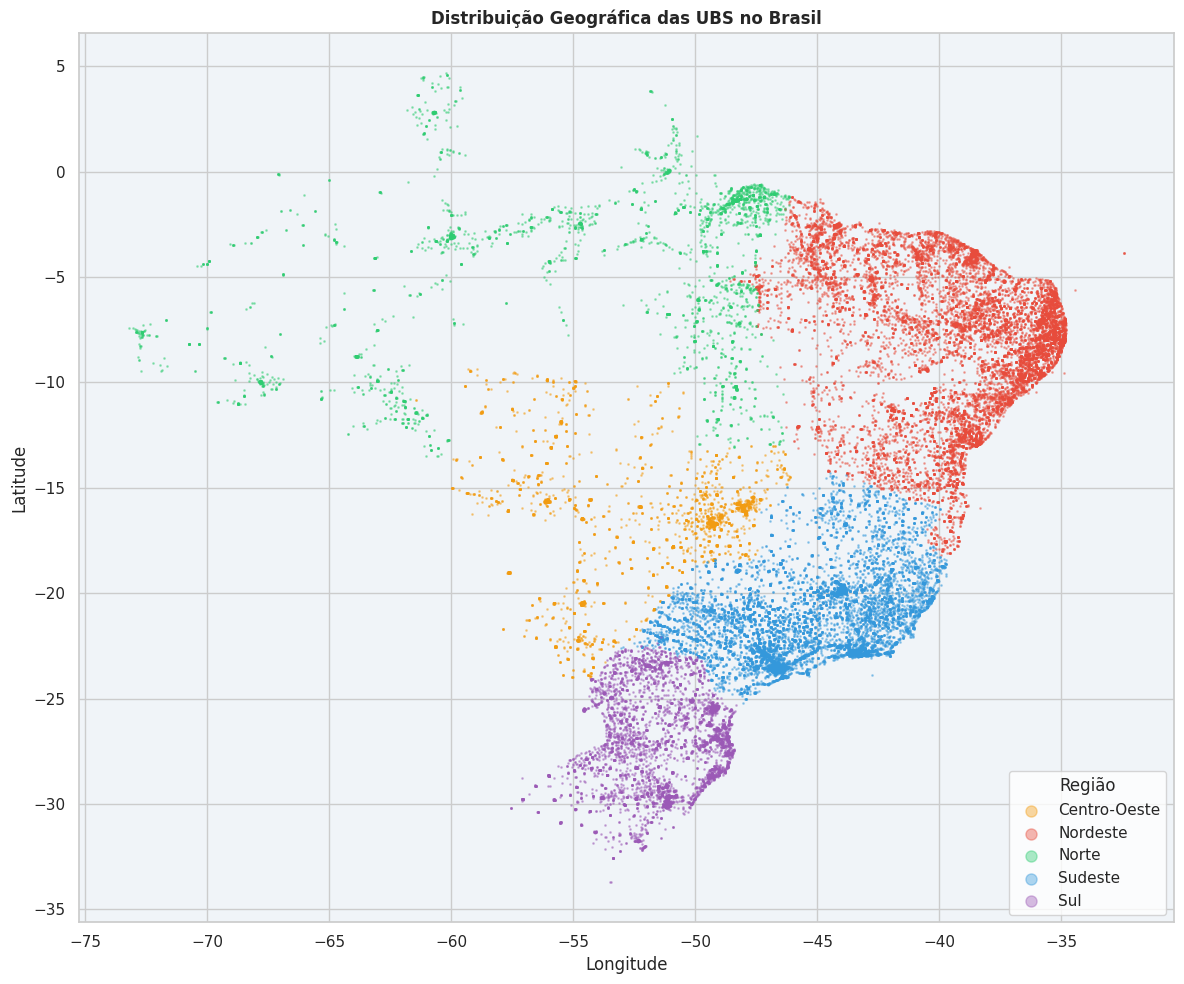


UBS plotadas (coordenadas válidas): 45,743 de 47,673 (96.0%)

UBS por Região:
REGIAO
Nordeste        17576
Sudeste         14363
Sul              6470
Norte            3886
Centro-Oeste     3448


In [10]:
# Filtrar apenas coordenadas válidas dentro dos limites do Brasil
df_geo = df[
    df['LATITUDE'].between(-35, 5) &
    df['LONGITUDE'].between(-75, -30)
].copy()

# Mapear regiões
regiao_map = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte',
    'RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste',
    'PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}
df_geo['REGIAO'] = df_geo['UF_SIGLA'].map(regiao_map)

cores = {
    'Norte':'#2ECC71', 'Nordeste':'#E74C3C',
    'Centro-Oeste':'#F39C12', 'Sudeste':'#3498DB', 'Sul':'#9B59B6'
}

fig, ax = plt.subplots(figsize=(12, 10))
for regiao, grupo in df_geo.groupby('REGIAO'):
    ax.scatter(grupo['LONGITUDE'], grupo['LATITUDE'],
               s=1, alpha=0.4, label=regiao, color=cores.get(regiao, 'gray'))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica das UBS no Brasil', fontweight='bold')
ax.legend(markerscale=8, title='Região', loc='lower right')
ax.set_facecolor('#F0F4F8')
plt.tight_layout()
plt.show()

print(f"\nUBS plotadas (coordenadas válidas): {len(df_geo):,} de {len(df):,} ({len(df_geo)/len(df)*100:.1f}%)")
print("\nUBS por Região:")
print(df_geo['REGIAO'].value_counts().to_string())